In [1]:
import sys
import pandapower as pp
import pandapower.networks as nw
import pandas as pd
import nbformat
import matplotlib.pyplot as plt
from pandapower.plotting.plotly import simple_plotly
from pandapower.plotting.plotly import pf_res_plotly
import copy
import pandapower as pp
from pandapower.plotting.plotly import simple_plotly
from pandapower.plotting.plotly import pf_res_plotly
from pathlib import Path
import os
import numpy as np




# Step 5



Create the network

Step 5 Instructions: to minimise the losses we need to have all the lines have the least Current possible (more balanced network)=> Minimise the Current on all the lines. We need to change the scheduler of the charging for this.  (Pandapower has a loss value )=> can also be used 


Processing schedule_Airmee ...
  Testing 1 chargers ...
c:\Users\Johanna\Documents\KTH\optimization\Network_optmisation\data\Output\schedule_Airmee\schedule_Airmee.csv
(type=<class 'pyomo.core.base.constraint.IndexedConstraint'>) on block unknown
with a new Component (type=<class
'pyomo.core.base.constraint.IndexedConstraint'>). This is usually indicative
of a modelling error. To avoid this warning, use block.del_component() and
block.add_component().
ERROR: evaluating object as numeric value: P[0,1]
        (object: <class 'pyomo.core.base.var.VarData'>)
    No value for uninitialized VarData object P[0,1]
ERROR: evaluating object as numeric value: obj
        (object: <class 'pyomo.core.base.objective.ScalarObjective'>)
    No value for uninitialized VarData object P[0,1]
   Solver failed for 1 chargers: No value for uninitialized VarData object P[0,1]
  Testing 2 chargers ...
c:\Users\Johanna\Documents\KTH\optimization\Network_optmisation\data\Output\schedule_Airmee\schedule_Airmee

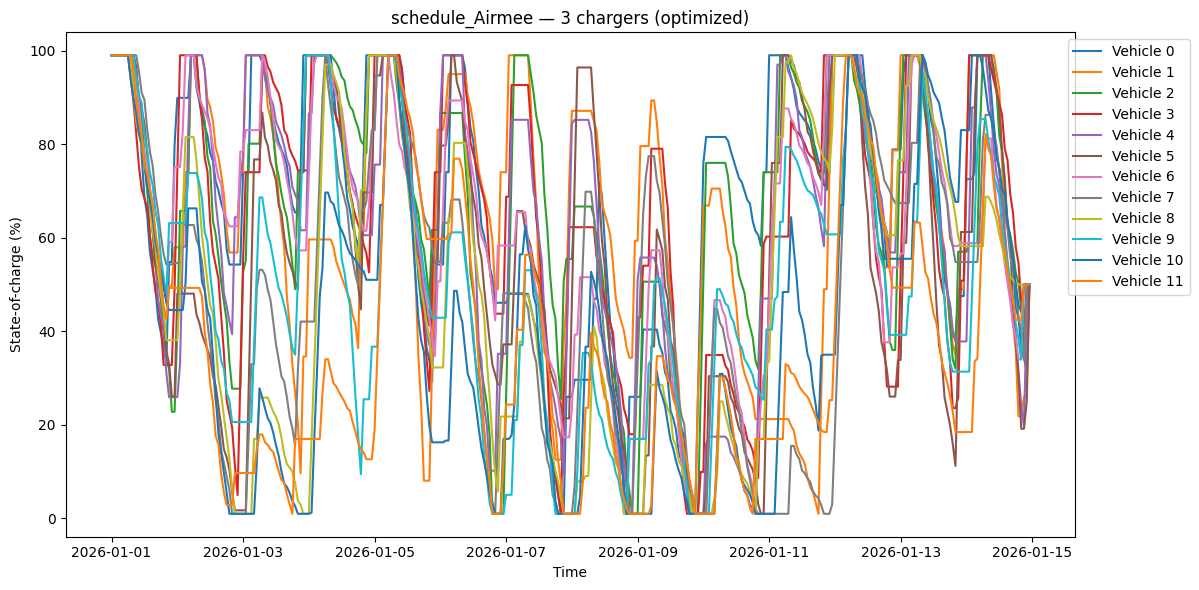

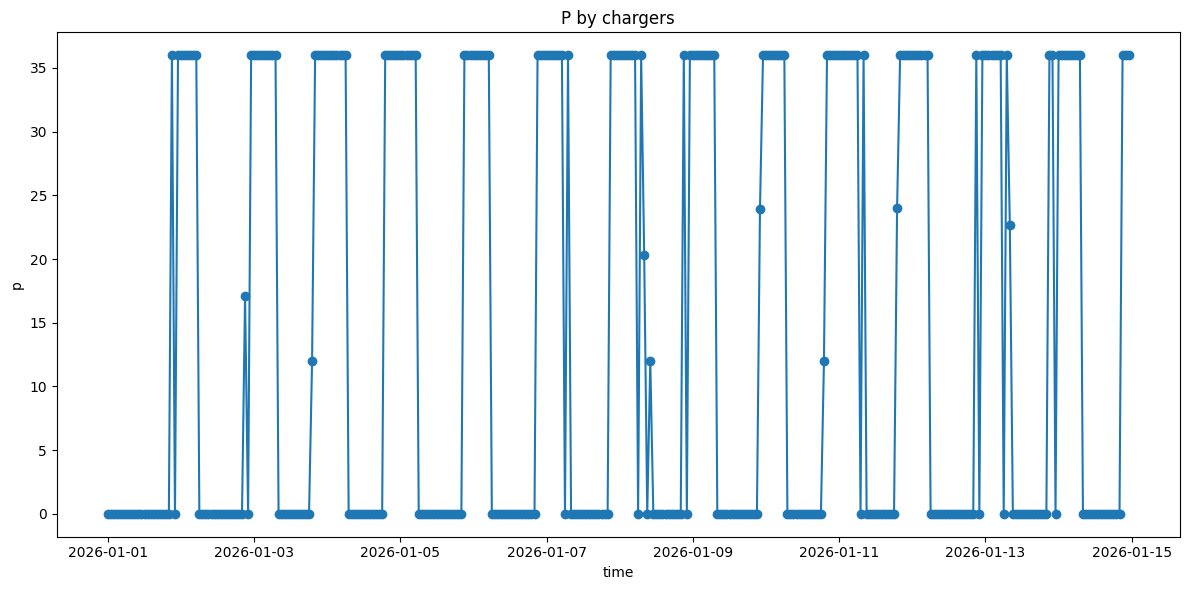

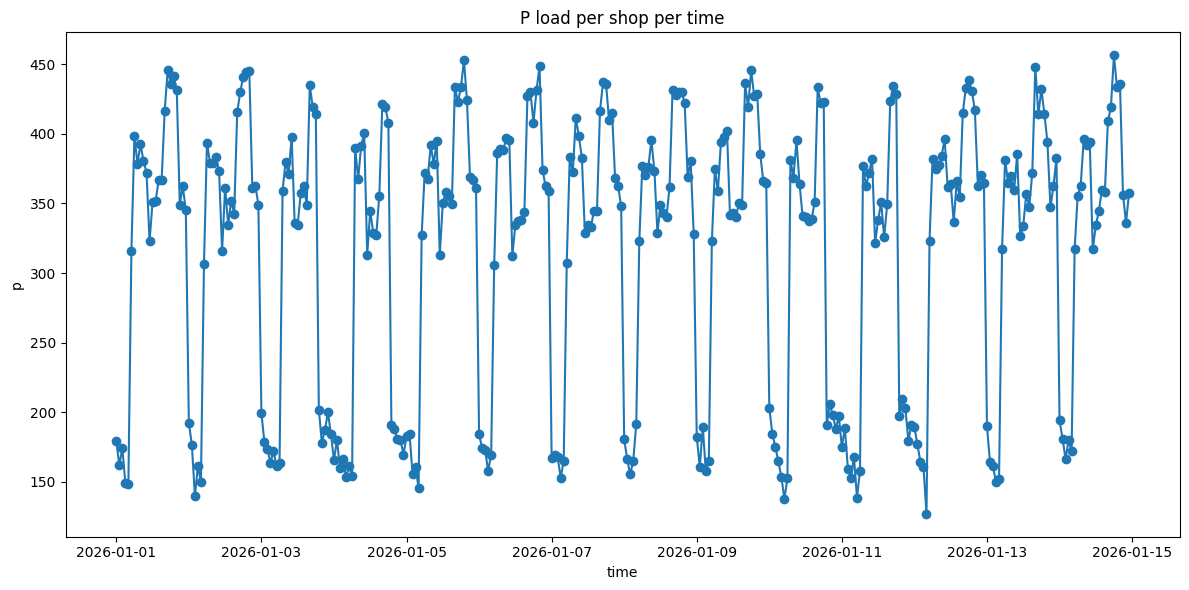

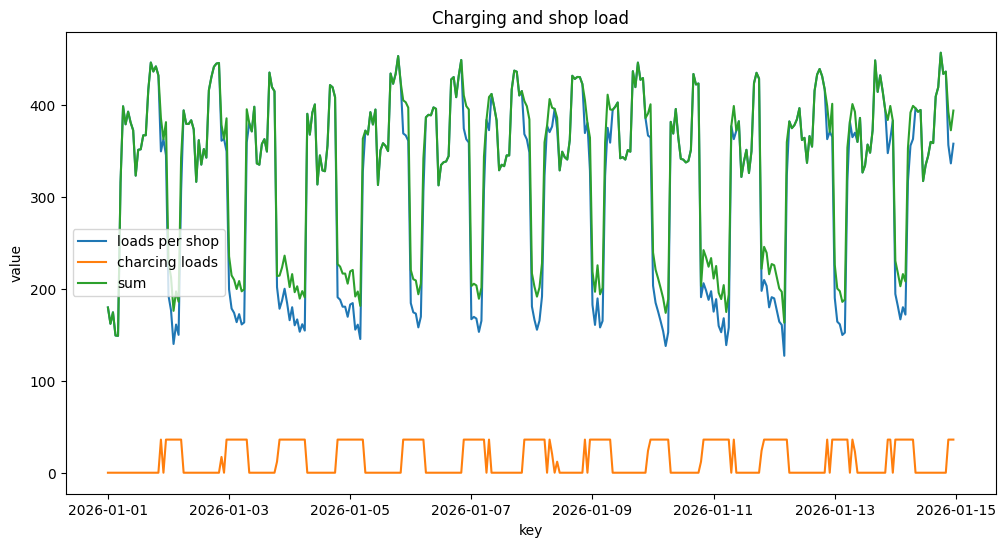


Summary:
 schedule_Airmee: 3 chargers (reason=ok)

Processing schedule_Postnord ...
  Testing 1 chargers ...
c:\Users\Johanna\Documents\KTH\optimization\Network_optmisation\data\Output\schedule_Postnord\schedule_Postnord.csv
(type=<class 'pyomo.core.base.constraint.IndexedConstraint'>) on block unknown
with a new Component (type=<class
'pyomo.core.base.constraint.IndexedConstraint'>). This is usually indicative
of a modelling error. To avoid this warning, use block.del_component() and
block.add_component().
ERROR: evaluating object as numeric value: P[0,1]
        (object: <class 'pyomo.core.base.var.VarData'>)
    No value for uninitialized VarData object P[0,1]
ERROR: evaluating object as numeric value: obj
        (object: <class 'pyomo.core.base.objective.ScalarObjective'>)
    No value for uninitialized VarData object P[0,1]
   Solver failed for 1 chargers: No value for uninitialized VarData object P[0,1]
  Testing 2 chargers ...
c:\Users\Johanna\Documents\KTH\optimization\Networ

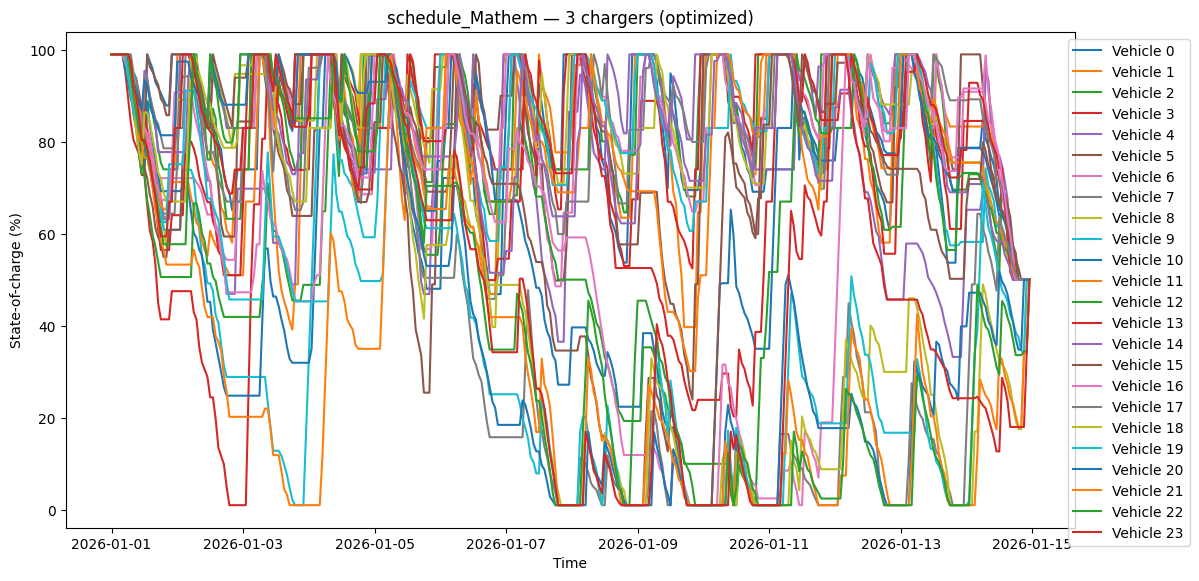

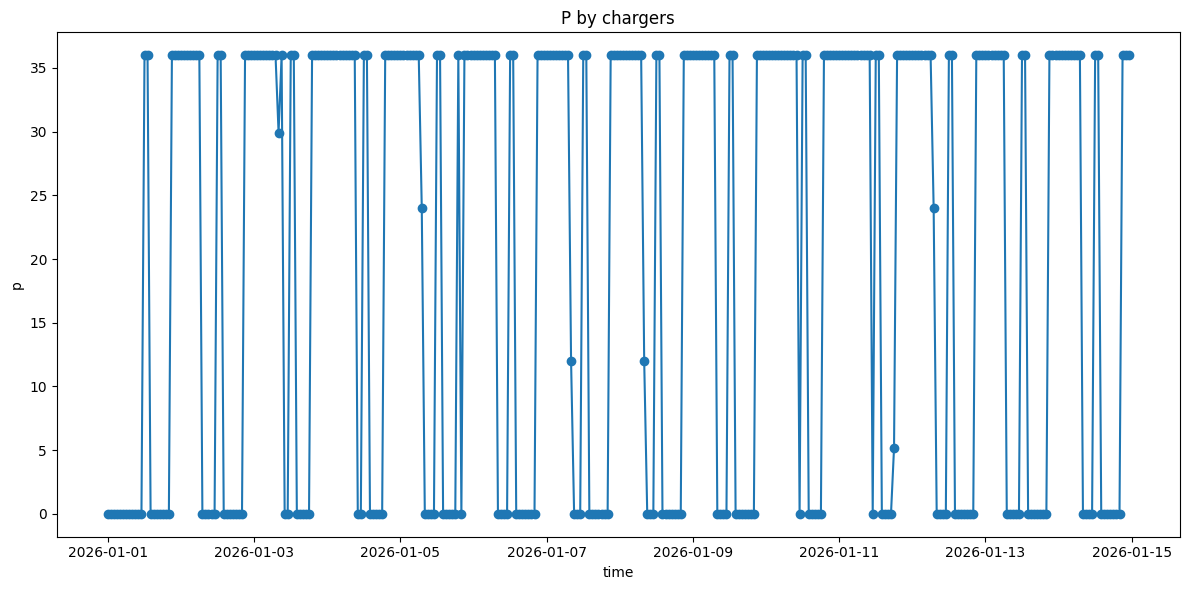

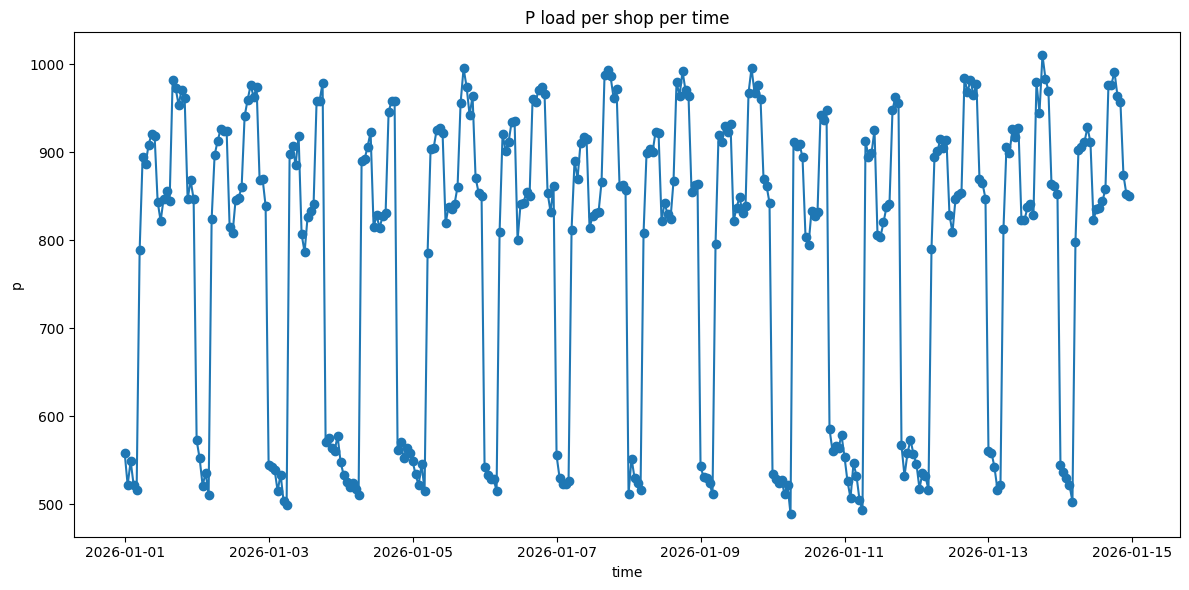

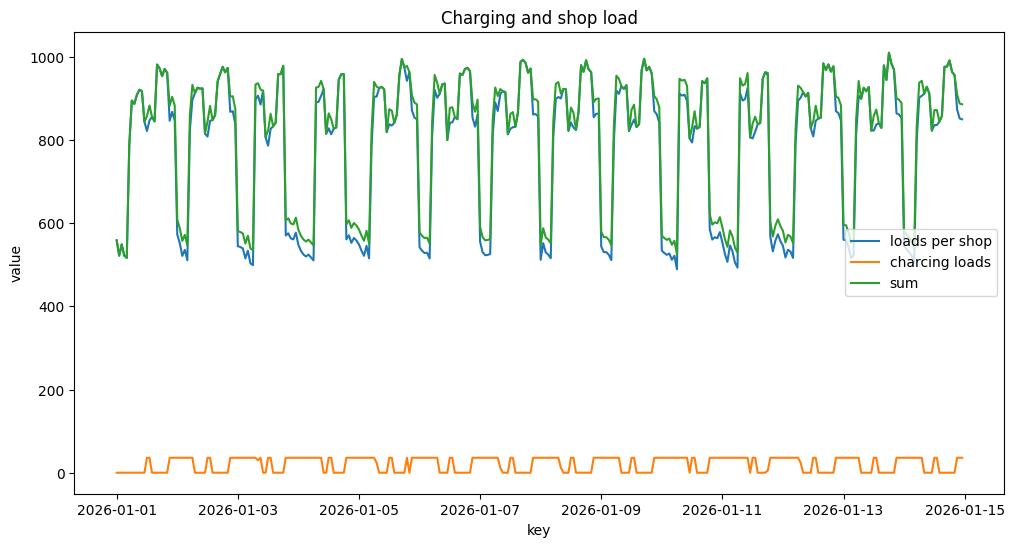


Summary:
 schedule_Airmee: 3 chargers (reason=ok)
 schedule_Postnord: None chargers (reason=not_feasible)
 schedule_Mathem: 3 chargers (reason=ok)

Processing schedule_ICA ...
  Testing 1 chargers ...
c:\Users\Johanna\Documents\KTH\optimization\Network_optmisation\data\Output\schedule_ICA\schedule_ICA.csv
(type=<class 'pyomo.core.base.constraint.IndexedConstraint'>) on block unknown
with a new Component (type=<class
'pyomo.core.base.constraint.IndexedConstraint'>). This is usually indicative
of a modelling error. To avoid this warning, use block.del_component() and
block.add_component().
ERROR: evaluating object as numeric value: P[0,1]
        (object: <class 'pyomo.core.base.var.VarData'>)
    No value for uninitialized VarData object P[0,1]
ERROR: evaluating object as numeric value: obj
        (object: <class 'pyomo.core.base.objective.ScalarObjective'>)
    No value for uninitialized VarData object P[0,1]
   Solver failed for 1 chargers: No value for uninitialized VarData object 

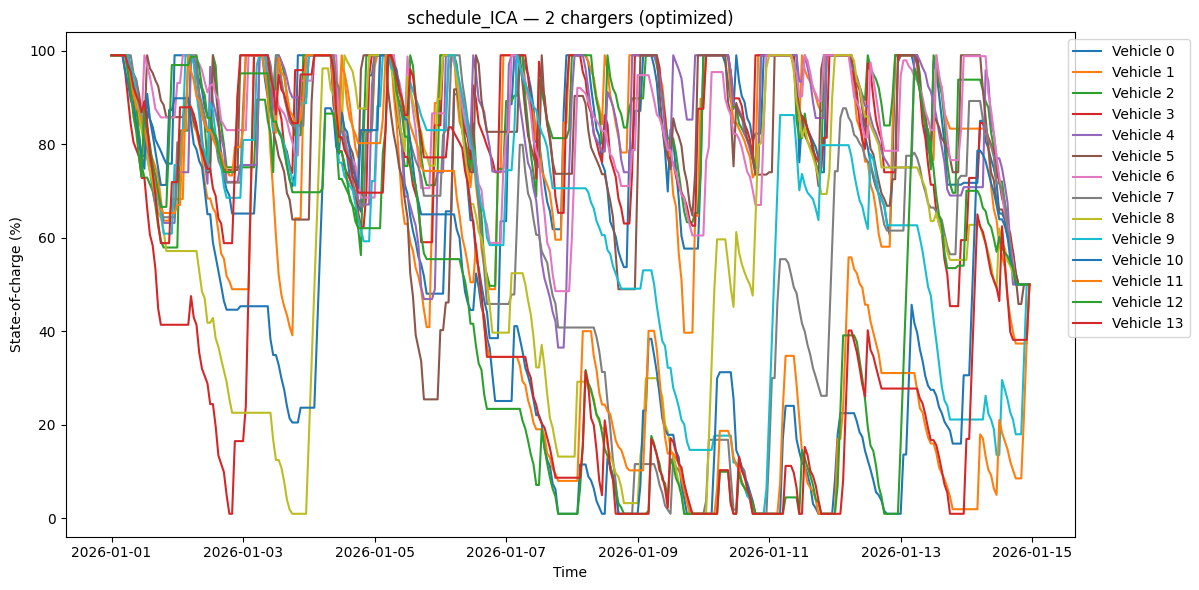

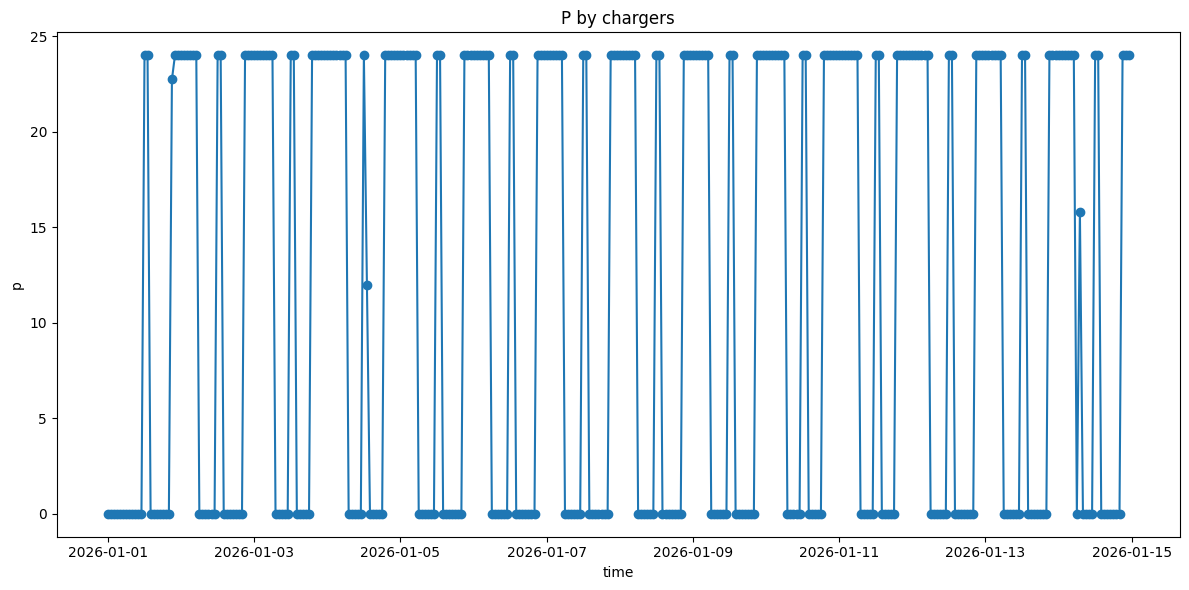

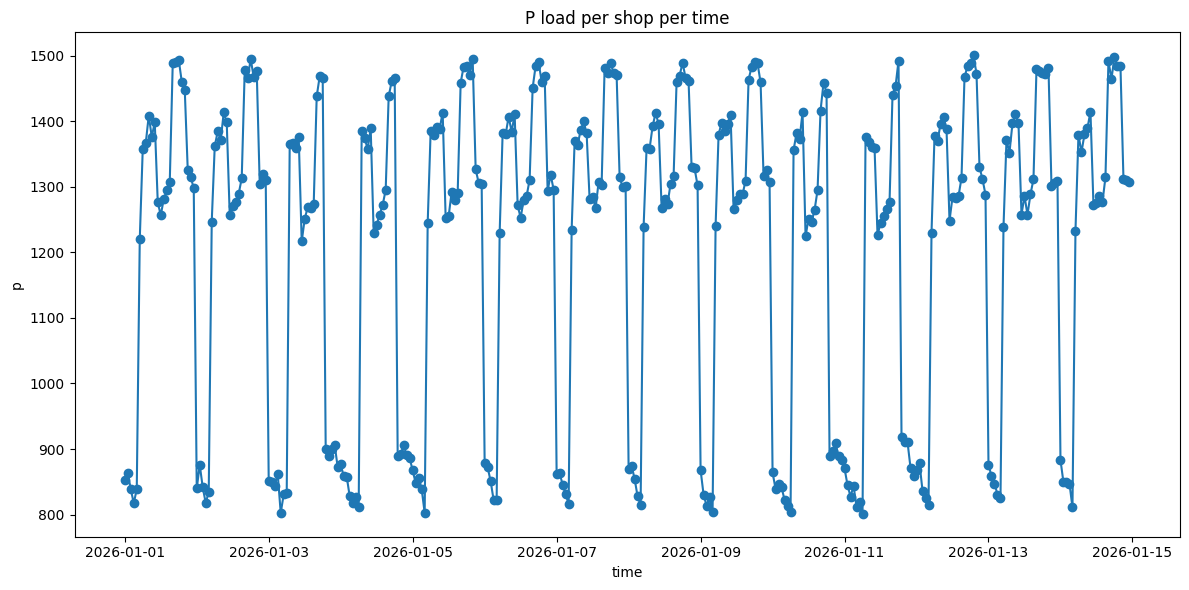

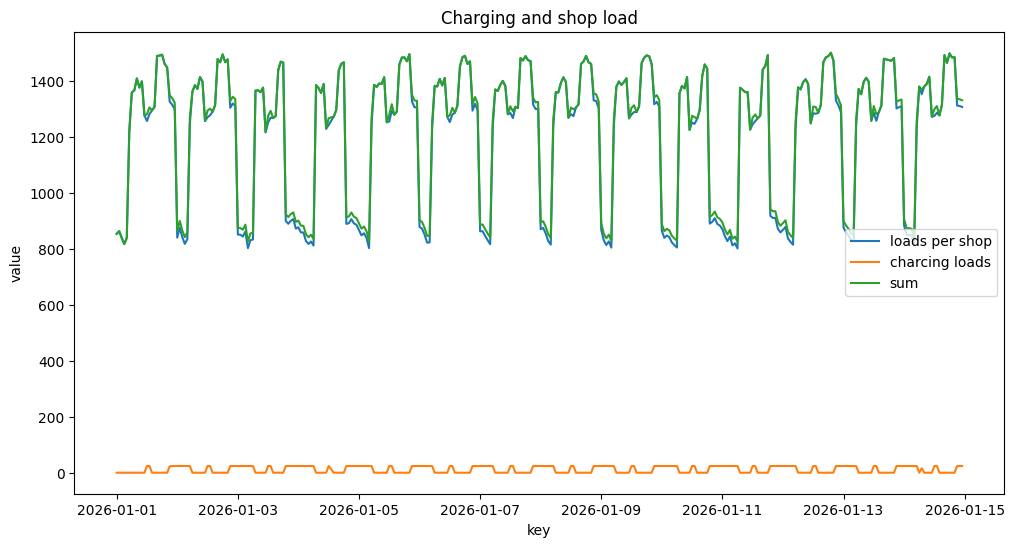


Summary:
 schedule_Airmee: 3 chargers (reason=ok)
 schedule_Postnord: None chargers (reason=not_feasible)
 schedule_Mathem: 3 chargers (reason=ok)
 schedule_ICA: 2 chargers (reason=ok)


In [2]:

import pandas as pd
import numpy as np
from pathlib import Path
import os
from datetime import timedelta
import math
import csv

# Pyomo imports
from pyomo.environ import (
    ConcreteModel, Var, Set, Param, Objective, Constraint, NonNegativeReals,
    Reals, SolverFactory, value, summation
)

import matplotlib.pyplot as plt

# -------------------------
# Config / mappings (same as you had)
# -------------------------
vehicle_charging_limits = {"Renault": 80.0, "Toyota": 100.0}   # kW inlet per vehicle type
battery_capacities = {"Renault": 48.0, "Toyota": 75.0}        # kWh per vehicle type
SOC_max_percentage = 0.99  # max state-of-charge fraction (to avoid overcharging)
SOC_min_percentage = 0.01  # min state-of-charge fraction (to avoid deep discharge)
SOC_last_time_step_percentage = 0.5 # the percentage of SOC at the last time step

# Charger capacity per physical charger (kW)
FAST_AC_CAPACITY_KW = 12.0



# ------------- 2. Read freight load profiles -------------
file_path_loads = "Load_profiles_Freight transports.xlsx"
load_profile = pd.read_excel(file_path_loads)
load_profile["Datetime"] = pd.to_datetime(
    load_profile["Date"].astype(str) + " " + load_profile["Time"].astype(str)
).dt.tz_localize(None)
load_profile = load_profile.set_index("Datetime")
shops = ["ICA", "Mathem", "Postnord", "Airmee"]
load_profile = load_profile[shops]



# -------------------------
# Core optimizer: optimize energy cost for one shop CSV and fixed number of chargers
# -------------------------
def optimize_shop_energy_cost(file_path,
                              n_chargers,
                              price_series,
                              solver_name='glpk',
                              verbose=False):
    """
    Build and solve a Pyomo LP that minimizes energy cost for charging
    with a fixed number of chargers.

    Parameters
    ----------
    file_path : str or Path
        Path to shop schedule CSV file (same layout you used: columns include
        'date', 'VehicleID', 'VehicleType', 'Location', 'Consumption_kWh').
    n_chargers : int
        Fixed number of chargers available at the depot.
    price_series : pandas.Series or None
        Optional electricity price indexed by timestamps. If None, a flat price 0.20 €/kWh is used.
    solver_name : str
        Pyomo solver name to attempt. Default 'glpk'. Will try 'cbc' if 'glpk' fails.
    verbose : bool
        If True print solver output.

    Returns
    -------
    dict
        result = {
            'status': solver status string,
            'objective': objective value (€/period),
            'P': dict {(vid, ts): value} charging powers (kW),
            'SOC': dict {vid: [SOC time series in kWh]},
            'time_index': time index (list of timestamps),
            'n_chargers': n_chargers
        }
    """

    shop_name = (str(file_path).split(".")[0]).split("_")[-1]

    file_path = Path(file_path)
    print(file_path)
    if not file_path.exists():
        raise FileNotFoundError(file_path)

    df = pd.read_csv(file_path)
    if 'date' not in df.columns:
        raise ValueError("CSV must have a 'date' column with timestamps.")
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)

    # Unique sorted time points
    time_index = sorted(df['date'].unique())
    T = len(time_index)
    if T < 1:
        raise ValueError("No timestamps found in file.")

    # Map timestamps to integer indices for Pyomo (1..T)
    time_to_idx = {ts: idx+1 for idx, ts in enumerate(time_index)}
    idx_to_time = {idx+1: ts for idx, ts in enumerate(time_index)}

    # Compute delta_t per time step (hours). For last step we reuse previous delta.
    delta_hours = {}
    for idx in range(1, T+1):
        if idx == 1:
            # for first time-step, if there is a second timestamp use difference,
            # otherwise default to 1 hour
            if T >= 2:
                dt = (idx_to_time[2] - idx_to_time[1]).total_seconds() / 3600.0
            else:
                dt = 1.0
        else:
            dt = (idx_to_time[idx] - idx_to_time[idx-1]).total_seconds() / 3600.0
        # safety: nonzero positive
        if dt <= 0:
            dt = 1.0
        delta_hours[idx] = dt

    # Vehicles
    vehicles = sorted(df['VehicleID'].unique())
    if len(vehicles) == 0:
        raise ValueError("No vehicles found in the schedule CSV.")

    # Vehicle type mapping, inlet and capacity parameters
    vehicle_types = df.groupby('VehicleID')['VehicleType'].first().to_dict()
    Pmax_by_vehicle = {vid: vehicle_charging_limits.get(vehicle_types.get(vid), FAST_AC_CAPACITY_KW)
                       for vid in vehicles}
    Cap_by_vehicle = {vid: battery_capacities.get(vehicle_types.get(vid), 48.0)
                      for vid in vehicles}

    # Build E_drive[i,t] (consumption) and I[i,t] (availability: 1 if at depot)
    # We'll aggregate rows per timestamp & vehicle (if duplicates present sum consumption and take Location=1 if any)
    idx_cols = ['VehicleID', 'date']
    agg = df.groupby(idx_cols).agg({
        'Consumption_kWh': 'sum',
        'Location': 'max'   # assume Location==1 means at depot
    }).reset_index()

    # initialize dictionaries
    E_drive = {(vid, t): 0.0 for vid in vehicles for t in range(1, T+1)}
    I_at_depot = {(vid, t): 0 for vid in vehicles for t in range(1, T+1)}

    for _, row in agg.iterrows():
        vid = row['VehicleID']
        ts = row['date']
        idx = time_to_idx[ts]
        E_drive[(vid, idx)] = float(row.get('Consumption_kWh', 0.0))
        I_at_depot[(vid, idx)] = 1 if int(row.get('Location', 0)) == 1 else 0

    # Electricity price per time index
    if price_series is None:
        # default flat price
        flat_price = 0.20  # €/kWh
        price_by_idx = {t: flat_price for t in range(1, T+1)}
    else:
        # expect price_series indexed by timestamps
        if not isinstance(price_series, pd.Series):
            # try reading CSV or dict-like
            raise ValueError("price_series must be a pandas.Series indexed by the same timestamps as 'date'.")
        # reindex/align - if missing timestamps in provided series, fill with last valid or flat default
        ps = price_series.copy()
        ps.index = pd.to_datetime(ps.index, format = '%d.%m.%Y %H:%M')
        price_by_idx = {}
        for idx in range(1, T+1):
            try:
                ts = idx_to_time[idx]
                price_by_idx[idx] = ps.iloc[idx-1]
            except:
                raise ValueError("error in creating price indexes")
            
    
    shop_loads = load_profile[shop_name] / 1000.0
    shop_loads = shop_loads.to_dict()
    shop_loads_dic = {}

    for ts, load in shop_loads.items():
        idx = time_to_idx[ts]
        shop_loads_dic[idx] = float(load)

    # -------------------------
    # Build Pyomo model
    # -------------------------
    model = ConcreteModel()

    # Sets
    model.VEH = Set(initialize=vehicles, ordered=True)
    model.TIME = Set(initialize=list(range(1, T+1)), ordered=True)

    # Parameters
    model.Cap = Param(model.VEH, initialize=Cap_by_vehicle, within=Reals)
    model.PmaxVeh = Param(model.VEH, initialize=Pmax_by_vehicle, within=Reals)
    model.Edrive = Param(model.VEH, model.TIME, initialize=E_drive, within=Reals)
    model.Avail = Param(model.VEH, model.TIME, initialize=I_at_depot, within=Reals)
    model.dt = Param(model.TIME, initialize=delta_hours, within=Reals)
    model.price = Param(model.TIME, initialize=price_by_idx, within=Reals)
    model.n_chargers = Param(initialize=int(n_chargers))
    model.P_charger = Param(initialize=float(FAST_AC_CAPACITY_KW))
    model.SOC_max_percentage = Param(initialize=SOC_max_percentage) 
    model.SOC_min_percentage = Param(initialize=SOC_min_percentage)
    model.Time_steps_amount = Param(initialize=T)
    model.SOC_last_time_step_percentage = Param(initialize=SOC_last_time_step_percentage)
    model.Shop_freights = Param(model.TIME, initialize=shop_loads_dic, within=Reals)


    # Variables: P[veh,time] (kW) and SOC[veh,time] (kWh)
    model.P = Var(model.VEH, model.TIME, domain=NonNegativeReals)
    model.SOC = Var(model.VEH, model.TIME, domain=NonNegativeReals)
    model.z = Var(domain=NonNegativeReals)

 

    def obj_rule(m):
        return sum(m.Shop_freights[t] * m.P[v, t] * m.dt[t] for v in m.VEH for t in m.TIME)
    model.obj = Objective(rule=obj_rule, sense=1) 

    # Constraints

    '''
    def capping_rule(m, t):
        return sum(m.P[v, t] for v in m.VEH) + m.Shop_freights[t] >= m.z
    model.capping = Constraint(model.TIME, rule=capping_rule)
    '''

    # 1) Charging availability and per-vehicle max inlet: P_i_t <= Avail_i_t * PmaxVeh_i
    def p_max_rule(m, v, t):
        return m.P[v, t] <= m.Avail[v, t] * m.PmaxVeh[v]
    model.p_max_con = Constraint(model.VEH, model.TIME, rule=p_max_rule)
    

    # 2) Charger capacity (shared): sum_i P_i_t <= n_chargers * P_charger
    def charger_cap_rule(m, t):
        return sum(m.P[v, t] for v in m.VEH) <= m.n_chargers * m.P_charger
    model.charger_cap_con = Constraint(model.TIME, rule=charger_cap_rule)


    # 2) Charger capacity (shared): sum_i P_i_t <= n_chargers * P_charger
    def charger_cap_rule(m, t):
        return sum(m.P[v, t] for v in m.VEH) <= m.n_chargers * m.P_charger
    model.charger_cap_con = Constraint(model.TIME, rule=charger_cap_rule)

    def charger_cap_rule_unique(m, v, t):
        return m.P[v, t]  <=  m.P_charger
    model.charger_cap_con_uniq = Constraint(model.VEH, model.TIME, rule=charger_cap_rule_unique)


    # 3) SOC dynamics:
    # For t == first index: SOC[v,1] = Cap_v - Edrive[v,1] + P[v,1]*dt[1]
    def soc_first_rule(m, v):
        t = 1
        return m.SOC[v, t] == m.Cap[v] * m.SOC_max_percentage - m.Edrive[v, t] + m.P[v, t] * m.dt[t]
    model.soc_first_con = Constraint(model.VEH, rule=soc_first_rule)

    # For t > 1: SOC[v,t] = SOC[v,t-1] - Edrive[v,t] + P[v,t]*dt[t]
    def soc_evol_rule(m, v, t):
        if t == 1:
            return Constraint.Skip
        return m.SOC[v, t] == m.SOC[v, t-1] - m.Edrive[v, t] + m.P[v, t] * m.dt[t]
    model.soc_evol_con = Constraint(model.VEH, model.TIME, rule=soc_evol_rule)

    # 4) Battery limits: 0 <= SOC <= Cap
    def soc_ub_rule(m, v, t):
        return m.SOC[v, t] <= m.Cap[v] * m.SOC_max_percentage
    model.soc_ub_con = Constraint(model.VEH, model.TIME, rule=soc_ub_rule)
    
    def soc_lb_rule(m, v, t):
        return m.SOC[v, t] >= m.Cap[v]*m.SOC_min_percentage
    model.soc_lb_con = Constraint(model.VEH, model.TIME, rule=soc_lb_rule)

    # at midnight of the last day, the soc should be 50 %  
    def soc_end_rule(m, v):
        t = m.Time_steps_amount
        return m.SOC[v, t] == m.Cap[v] * m.SOC_last_time_step_percentage
    model.soc_end_con = Constraint(model.VEH, rule=soc_end_rule)




    # Lower bound of SOC already enforced by domain NonNegativeReals

    # -------------------------
    # Solve
    # -------------------------
    # Attempt to create a solver and solve
    solver = None
    solver_try_order = [solver_name, 'cbc', 'glpk'] if solver_name != 'glpk' else ['glpk', 'cbc']
    solver_available = False
    last_solver_err = None
    for sname in solver_try_order:
        try:
            solver = SolverFactory(sname)
            if solver is None:
                continue
            # Some backends require 'executable' to be present; we'll just attempt solve and catch exceptions
            res = solver.solve(model, tee=verbose)
            solver_available = True
            break
        except Exception as e:
            last_solver_err = e
            solver = None
            continue

    if not solver_available:
        raise RuntimeError(f"No solver available/working. Tried {solver_try_order}. "
                           f"Last error: {last_solver_err}")

    # Read out solution
    # objective value
    obj_val = value(model.obj)

    P_sol = {}
    P_per_time = {}
    SOC_traces = {v: [] for v in vehicles}
    SOC_traces_percentage = {v: [] for v in vehicles}
    for t in model.TIME:
        all_P = 0.0
        for v in model.VEH:
            P_sol[(v, idx_to_time[t])] = float(value(model.P[v, t]))
            all_P += float(value(model.P[v, t]))
        P_per_time[idx_to_time[t]] = all_P

    for v in vehicles:
        for t in model.TIME:
            SOC_traces[v].append(float(value(model.SOC[v, t])))
            SOC_traces_percentage[v].append(float(value(model.SOC[v, t]/model.Cap[v])))

    n_vehicles = len(vehicles)
    if n_chargers > n_vehicles:
        raise RuntimeError(f"No feasible solution found, number of chargers", n_chargers, "would be higher than number of vehicles", n_vehicles)


    result = {
        'status': str(res.solver.termination_condition) if hasattr(res, 'solver') else 'unknown',
        'objective': obj_val,
        'P': P_sol,
        'P_time' : P_per_time,
        'SOC': SOC_traces,
        'time_index': [idx_to_time[t] for t in model.TIME],
        'n_chargers': int(n_chargers),
        'solver': solver,
        'SOC_percentage' : SOC_traces_percentage
    }

    return result

# -------------------------
# Optional: plotting helper
# -------------------------
def plot_soc_from_result(result, shop, title=None, save_fig=False, out_path=None):
    time = result['time_index']
    soc_percentage = result['SOC_percentage']
    p_shop = result['P_time']
    

    plt.figure(figsize=(12, 6))
    for vid, series in soc_percentage.items():
        series_pct = [s * 100.0 for s in series]  # convert to percentage
        plt.plot(time, series_pct, label=f"Vehicle {vid}")
        
    plt.xlabel("Time")
    plt.ylabel("State-of-charge (%)")
    if title is None:
        title = f"SOC over time — {result.get('n_chargers', '?')} chargers"
    plt.title(title)
    plt.legend(loc='upper right', bbox_to_anchor=(1.12, 1.0))
    plt.tight_layout()
    if save_fig:
        if out_path is None:
            out_path = Path("soc_plot.png")
        plt.savefig(out_path, dpi=150)
        print("Saved figure to", out_path)
    plt.show()


    plt.figure(figsize=(12, 6))
    xs, ys = zip(*sorted(p_shop.items()))  # sort by key for a proper line
    plt.plot(xs, ys, marker="o")
    plt.xlabel("time")
    plt.ylabel("p")
    plt.title("P by chargers")
    plt.tight_layout()
    plt.show()
        

    shop_name = shop.split("_")[1]
    shop_loads = load_profile[shop_name] # in kW
    shop_loads = shop_loads.to_dict()


    plt.figure(figsize=(12, 6))
    xs, ys = zip(*sorted(shop_loads.items()))  # sort by key for a proper line
    plt.plot(xs, ys, marker="o")
    plt.xlabel("time")
    plt.ylabel("p")
    plt.title("P load per shop per time")
    plt.tight_layout()
    plt.show()

   
   

    # Choose an order (sort to be explicit)
    plt.figure(figsize=(12, 6))
    x = sorted(shop_loads.keys())
    y1 = [shop_loads[k] for k in x]
    y2 = [p_shop[k] for k in x]
    y3 = [p_shop[k] + shop_loads[k] for k in x]

    plt.plot(x, y1, label="loads per shop")
    plt.plot(x, y2, label="charcing loads")
    plt.plot(x, y3, label="sum")
    plt.legend(); plt.xlabel("key"); plt.ylabel("value"); plt.title("Charging and shop load")
    plt.show()
        
 

    '''
    df = pd.DataFrame(
        [(v, t, val) for (v, t), val in p_shop.items()],
        columns=["veh", "time", "P"]
    ).sort_values("time")

    # One line per vehicle
    plt.figure(figsize=(10, 5))
    
    plt.plot(df.index, df["P"])   

    
    plt.figure(figsize=(10, 5))
    for veh, g in df.groupby("veh"):
        plt.plot(g["time"], g["P"], label=str(veh))
    


    plt.xlabel("Time")
    plt.ylabel("P")
    plt.title("Power by Vehicle over Time")
    plt.legend(ncols=2)          # adjust as you like
    plt.tight_layout()
    plt.show()
    '''

    '''

    ax.plot(ev_load_profile.index, ev_load_profile[shop], 
            linewidth=1.2, label=f"{shop}")
    ax.set_xlabel("Time")
    ax.set_ylabel("EV Charging Load (kW)")
    ax.set_title("EV Charging Loads by Shop — 2 weeks (hourly)")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()
    '''



def open_price_file():
    
    prices = {}
    date_format = '%d.%m.%Y %H:%M'

    with open("Prices.csv", newline="", encoding="utf-8") as f:
        reader = csv.reader(f)              
        header = next(reader, None)        
        for row in reader:
            from_time = row[0].split(" - ")[0]
            prices[from_time] = float(row[1])
    prices_pd = pd.Series(prices)
    return prices_pd


shop_optimized_charging_schedules = {}

# -------------------------
# Example / if called as script
# -------------------------
if __name__ == "__main__":
    base_path = Path(os.getcwd()).parent / "data" / "Output"
    shops = ["schedule_Airmee", "schedule_Postnord", "schedule_Mathem", "schedule_ICA"]

    results = {}
    MAX_CHARGERS_TO_TEST = 29

    for shop in shops:
        shop_folder = base_path / shop
        file = shop_folder / f"{shop}.csv"
        if not file.exists():
            print(f"[WARN] file not found: {file}")
            results[shop] = {'min_chargers': None, 'reason': 'file_missing'}
            continue

        print(f"\nProcessing {shop} ...")

        # Test decreasing number of chargers: 20 down to 1
        found = False
        best_trace = None
        best_cost = None
        prices = open_price_file()
        #for n_ch in range(1, MAX_CHARGERS_TO_TEST, 1):
        for n_ch in range(1,MAX_CHARGERS_TO_TEST):
            print(f"  Testing {n_ch} chargers ...")
            try:
                res = optimize_shop_energy_cost(file, n_chargers=n_ch, price_series=prices, solver_name='glpk', verbose=False)
            except Exception as e:
                print(f"   Solver failed for {n_ch} chargers: {e}")
                continue

            # Evaluate feasibility: if SOC never goes below 0
            feasible = all(all(val >= -1e-6 for val in soc_list) for soc_list in res['SOC'].values())

            if feasible:
                print(f"   ✅ Feasible with {n_ch} chargers, cost = {res['objective']:.2f} €")
                found = True
                best_trace = res
                best_cost = res['objective']
                best_trace_percentage = res['SOC_percentage']
                shop_name = shop.replace("schedule_", "")
                shop_optimized_charging_schedules[shop_name] = res["P_time"] 
                # continue searching for smaller feasible? Since we go 20→1, break on first feasible
                break
            else:
                print(f"   ❌ Infeasible with {n_ch} chargers (battery empty at some point)")

        if found:
            print(f"  -> Minimum chargers required: {n_ch}")
            results[shop] = {
                'min_chargers': n_ch,
                'objective': best_cost,
                'trace': best_trace,
                'trace_percentage': best_trace['SOC_percentage']
            }
            # Optionally plot SOC
            df = pd.read_csv(file)
            vehicle_types = df.groupby('VehicleID')['VehicleType'].first().to_dict()

            plot_soc_from_result(best_trace, shop, title=f"{shop} — {n_ch} chargers (optimized)", save_fig=False)
        else:
            print(f"  -> Not feasible with up to {MAX_CHARGERS_TO_TEST} chargers.")
            results[shop] = {'min_chargers': None, 'reason': 'not_feasible'}

        print("\nSummary:")
        for shop, info in results.items():
            print(f" {shop}: {info.get('min_chargers')} chargers (reason={info.get('reason','ok')})")


        #fig, ax = plt.subplots(figsize=(14, 6))
        


In [3]:
# ------------- 1. create network and apply initial change -------------
net0 = nw.create_cigre_network_mv(with_der=False)

net0.switch["closed"] = True  # close the tie switch

# scale down loads
net0.load['p_mw'] = net0.load['p_mw'] / 2.0
net0.load['q_mvar'] = net0.load['q_mvar'] / 2.0

base_loads = net0.load['p_mw'].copy()




# Initialize shop placements
shop_to_bus = {
    "ICA": 13,
    "Mathem": 6,
    "Postnord": 10,
    "Airmee": 6,
}


# Function to create network with shop loads
def create_network_with_shops(net_base, shop_mapping, timestamp, charging_loads):
    """Create a network with base loads + shop loads at specified buses"""
    net = copy.deepcopy(net_base)
    
    # Reset to base loads first
    net.load['p_mw'] = base_loads.copy()
    
    # Add shop loads to their respective buses
    for shop, bus in shop_mapping.items():
        if shop != "Postnord":   # delete this
            charging_load_shop = charging_loads[shop]
            if bus is not None:
                # Find if there's already a load at this bus
                existing_loads = net.load[net.load.bus == bus]
                
                if not existing_loads.empty:
                    # Add to existing load
                    load_idx = existing_loads.index[0]
                    add_mw_freight = load_profile.at[timestamp, shop] / 1000.0
                    net.load.at[load_idx, 'p_mw'] += add_mw_freight
                    add_mw_charging = charging_load_shop[timestamp] / 1000.0
                    net.load.at[load_idx, 'p_mw'] += add_mw_charging
                else:
                    # Create new load at this bus
                    add_mw_freight = load_profile.at[timestamp, shop] / 1000.0
                    add_mw_charging = charging_load_shop[timestamp] / 1000.0
                    add_mw = add_mw_charging + add_mw_freight
                    pp.create_load(net, bus=bus, p_mw=add_mw, q_mvar=0)
        
    return net


      


# ------------- 6. Run final simulation with all shops -------------
print("Running final simulation with all shops...")

line_indices = list(net0.line.index)
col_names = [f"line_{i}" for i in line_indices]
res_lines_final_losses = pd.DataFrame(index=load_profile.index, columns=col_names, dtype=float)




all_losses = 0.0

for ts_idx, ts in enumerate(load_profile.index):
    if ts_idx % 24 == 0:  # Print progress every 24 hours
        print(f"Final simulation progress: {ts}")
    
    net_final = create_network_with_shops(net0, shop_to_bus, ts, shop_optimized_charging_schedules)

    try:
        pp.runpp(net_final, calculate_voltage_angles=False)
        line_loading = net_final.res_line.loading_percent 
        line_losses = net_final.res_line.pl_mw
        trafo_loading = net_final.res_trafo.loading_percent
        bus_voltage = net_final.res_bus.vm_pu
        for li in line_indices:
            res_lines_final_losses.at[ts, f"line_{li}"] = line_losses.at[li]
            all_losses += line_losses.at[li]



    except Exception as e:
        print(f"Final power flow failed at {ts}: {e}")
        


print(all_losses)

Running final simulation with all shops...
Final simulation progress: 2026-01-01 00:00:00
Final simulation progress: 2026-01-02 00:00:00
Final simulation progress: 2026-01-03 00:00:00
Final simulation progress: 2026-01-04 00:00:00
Final simulation progress: 2026-01-05 00:00:00
Final simulation progress: 2026-01-06 00:00:00
Final simulation progress: 2026-01-07 00:00:00
Final simulation progress: 2026-01-08 00:00:00
Final simulation progress: 2026-01-09 00:00:00
Final simulation progress: 2026-01-10 00:00:00
Final simulation progress: 2026-01-11 00:00:00
Final simulation progress: 2026-01-12 00:00:00
Final simulation progress: 2026-01-13 00:00:00
Final simulation progress: 2026-01-14 00:00:00
36.99917469084357
